# Параметрическое исследование

Этот literate-скрипт добавляет дополнительное вычисление
для набора параметров. Изучается, как число философов
влияет на вероятность тупика
в классической сети и в сети с арбитром.

## Подключение библиотек

In [1]:
using DrWatson
@quickactivate "lab_05_models"

ENV["GKSwstype"] = "100"

include(joinpath(@__DIR__, "..", "src", "DiningPhilosophers.jl"))
using .DiningPhilosophers
using CSV
using DataFrames
using Plots

mkpath(datadir())
mkpath(plotsdir())

"/home/asvedjmina/university/imit-model/2026-1--study--simulation-modeling/labs/lab05/lab_05_models/plots"

## Набор параметров

Рассматриваются значения `N = 3:7`.
Для каждого значения выполняется серия
стохастических прогонов с разными `seed`.

In [2]:
philosopher_counts = 3:7
seeds = 1:16
tmax = 60.0

raw_scan = parameter_scan(philosopher_counts; seeds = seeds, tmax = tmax)
summary_scan = summarize_parameter_scan(raw_scan)

raw_scan
summary_scan

Row,model,philosophers,deadlock_probability,mean_deadlock_time,mean_final_eaters,mean_final_hungry,mean_events
,String,Int64,Float64,Float64?,Float64,Float64,Float64
1,classic,3,1.0,2.31997,0.0,3.0,6.1875
2,arbiter,3,0.0,missing,0.5,1.375,87.875
3,classic,4,1.0,4.62274,0.0,4.0,10.5625
4,arbiter,4,0.0,missing,0.375,2.1875,95.0
5,classic,5,1.0,8.95534,0.0,5.0,20.75
6,arbiter,5,0.0,missing,0.625,3.25,97.875
7,classic,6,1.0,4.32156,0.0,6.0,13.875
8,arbiter,6,0.0,missing,0.5,4.3125,94.1875
9,classic,7,1.0,5.99873,0.0,7.0,18.0625


## Визуализация параметрического анализа

На верхней панели показана вероятность deadlock,
на нижней — среднее время его наступления.

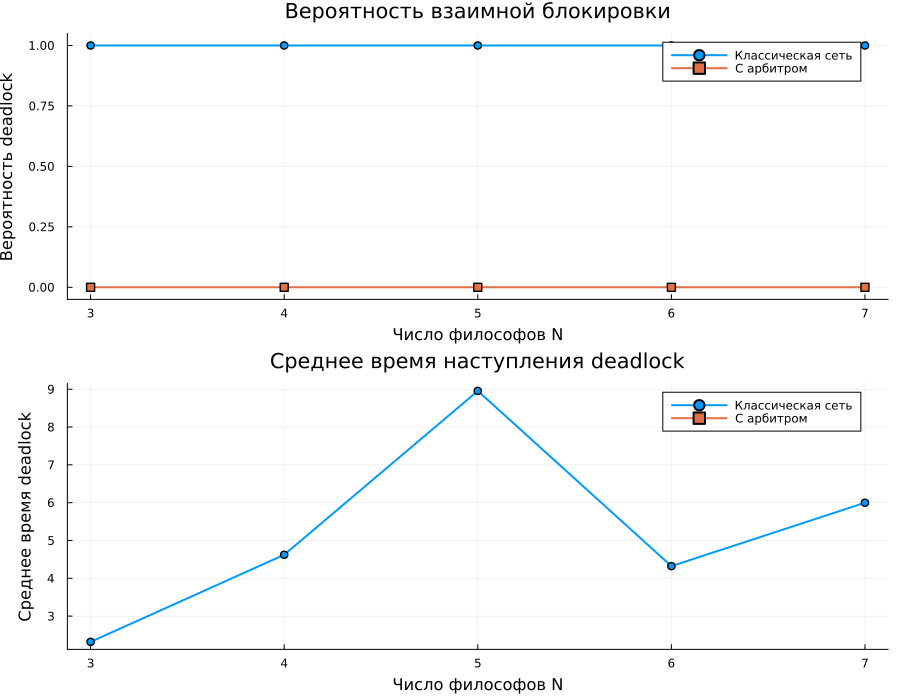

In [3]:
parameter_plot = plot_parameter_summary(summary_scan)
parameter_plot

## Интерпретация

1. Для классической сети вероятность deadlock
   быстро растёт с увеличением `N`.
2. В серии экспериментов с арбитром тупики не наблюдаются.
3. Среднее время наступления deadlock
   в классической сети остаётся конечным,
   что подтверждает необходимость механизма синхронизации.